# Continuous surrogates vs TBN on the Arabidopsis ISR dataset

This notebook is prepared to run in **Google Colab** and reproduce the experiments for the paper comparing:

- **Random Forest regression** on the raw continuous expression data
- **MLP regression** on the raw continuous expression data
- a **threshold Boolean network (TBN)** on the binarized data

The workflow includes:

1. loading the ISR dataset,
2. building one-step transitions,
3. rolling-origin evaluation,
4. one-step metrics,
5. multi-step rollout analysis,
6. interpretability plots.

In [ ]:
# =========================
# 1. Imports
# =========================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

## 2. Upload / load the CSV

In Colab, either:
- upload `dataGene.csv` manually, or
- mount Google Drive and point to its path.

This cell first looks for `/content/dataGene.csv`.
If the file is not there, upload it with the file picker.

In [ ]:
# =========================
# 2. Load the CSV
# =========================
from pathlib import Path

csv_path = Path("/content/dataGene.csv")

if not csv_path.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        if "dataGene.csv" not in uploaded:
            raise FileNotFoundError("Please upload a file named dataGene.csv")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find /content/dataGene.csv. "
            "Please upload dataGene.csv in Colab before continuing."
        ) from e

df = pd.read_csv("/content/dataGene.csv", sep=";")
df

,Time(h),PR1,PDF1.2,WRKY70,WRKY54,WRKY33,MYC2,ERF1,LOX2
0,0.0,1.986609,0.171415,-1.173110,-0.458324,4.424988,-0.184604,-0.380483,0.235496
1,0.5,3.395350,-0.388911,0.870193,0.356764,2.937891,0.145601,0.508974,0.419148
2,1.0,1.536523,2.564875,-0.049382,0.017384,1.304285,-0.091967,-0.875839,1.121276
3,3.0,-0.490100,0.593172,-0.391667,-0.431395,0.909736,0.290935,-0.125682,0.625985
4,6.0,-0.046488,0.368310,-0.697770,-0.834785,-0.244379,0.119312,0.757226,5.752236
5,9.0,0.971408,1.007404,0.620910,-0.135553,0.418617,-0.389206,0.835373,-0.036167
6,12.0,1.919402,8.410475,0.958097,0.290329,0.075051,-0.182073,0.965529,0.029954
7,18.0,6.547333,-2.526833,2.326297,0.547834,-1.671870,-0.193180,-0.585616,-5.873542
8,24.0,5.551651,-8.477788,-1.151199,-0.756221,0.265123,0.183138,0.648322,2.063770


## 3. Basic inspection

In [ ]:
# =========================
# 3. Basic inspection
# =========================
time_col = "Time(h)"
genes = [c for c in df.columns if c != time_col]

print("Columns:", df.columns.tolist())
print("Genes:", genes)
print("Shape:", df.shape)

display(df)

Columns: ['Time(h)', 'PR1', 'PDF1.2', 'WRKY70', 'WRKY54', 'WRKY33', 'MYC2', 'ERF1', 'LOX2']
Genes: ['PR1', 'PDF1.2', 'WRKY70', 'WRKY54', 'WRKY33', 'MYC2', 'ERF1', 'LOX2']
Shape: (9, 9)


,Time(h),PR1,PDF1.2,WRKY70,WRKY54,WRKY33,MYC2,ERF1,LOX2
0,0.0,1.986609,0.171415,-1.173110,-0.458324,4.424988,-0.184604,-0.380483,0.235496
1,0.5,3.395350,-0.388911,0.870193,0.356764,2.937891,0.145601,0.508974,0.419148
2,1.0,1.536523,2.564875,-0.049382,0.017384,1.304285,-0.091967,-0.875839,1.121276
3,3.0,-0.490100,0.593172,-0.391667,-0.431395,0.909736,0.290935,-0.125682,0.625985
4,6.0,-0.046488,0.368310,-0.697770,-0.834785,-0.244379,0.119312,0.757226,5.752236
5,9.0,0.971408,1.007404,0.620910,-0.135553,0.418617,-0.389206,0.835373,-0.036167
6,12.0,1.919402,8.410475,0.958097,0.290329,0.075051,-0.182073,0.965529,0.029954
7,18.0,6.547333,-2.526833,2.326297,0.547834,-1.671870,-0.193180,-0.585616,-5.873542
8,24.0,5.551651,-8.477788,-1.151199,-0.756221,0.265123,0.183138,0.648322,2.063770


## 4. Continuous and binary representations

We use:

- the **continuous** raw data for RF and MLP,
- the **binarized** data for the TBN, with the sign rule:
  - value > 0  → 1
  - value <= 0 → 0

We also include the time gap $(\Delta t)$ as an extra input for the continuous models.

In [ ]:
# =========================
# 4. Build continuous and binary views
# =========================
times = df[time_col].values.astype(float)
X_cont = df[genes].values[:-1]
Y_cont = df[genes].values[1:]

delta_t = (times[1:] - times[:-1]).reshape(-1, 1)

# Continuous inputs include Δt
X_cont_dt = np.hstack([X_cont, delta_t])

# Binary views
X_bin = (X_cont > 0).astype(int)
Y_bin = (Y_cont > 0).astype(int)

transition_labels = [
    f"{times[i]}→{times[i+1]}" for i in range(len(times) - 1)
]

print("X_cont_dt shape:", X_cont_dt.shape)
print("Y_cont shape:", Y_cont.shape)
print("X_bin shape:", X_bin.shape)
print("Y_bin shape:", Y_bin.shape)
print("Transitions:", transition_labels)

X_cont_dt shape: (8, 9)
Y_cont shape: (8, 8)
X_bin shape: (8, 8)
Y_bin shape: (8, 8)
Transitions: ['0.0→0.5', '0.5→1.0', '1.0→3.0', '3.0→6.0', '6.0→9.0', '9.0→12.0', '12.0→18.0', '18.0→24.0']


## 5. Plot the continuous trajectories

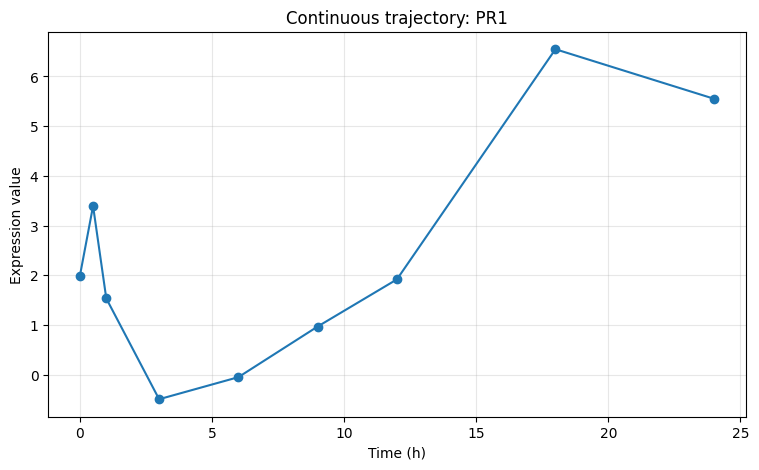

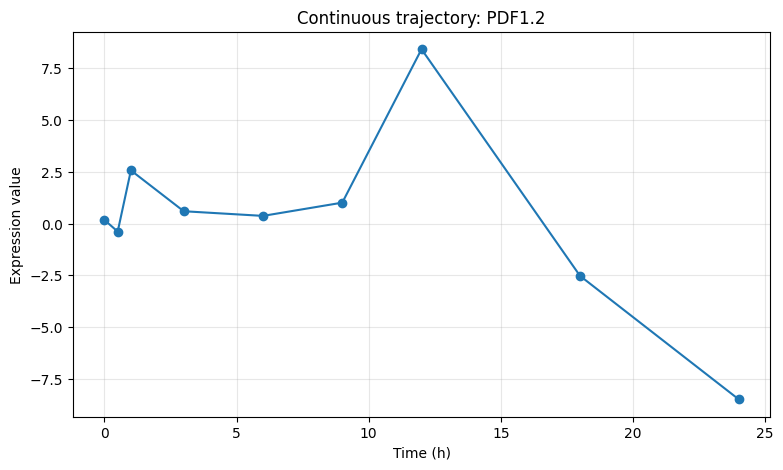

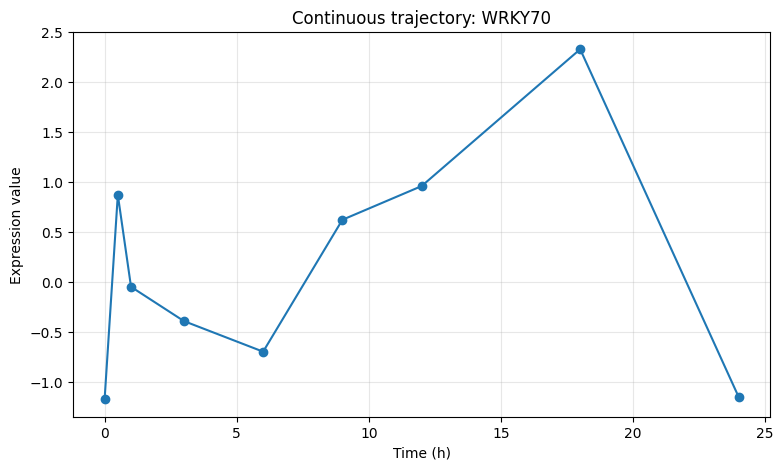

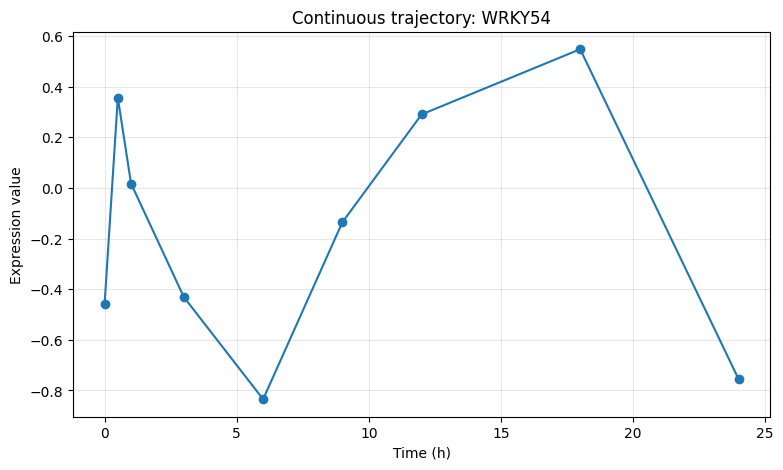

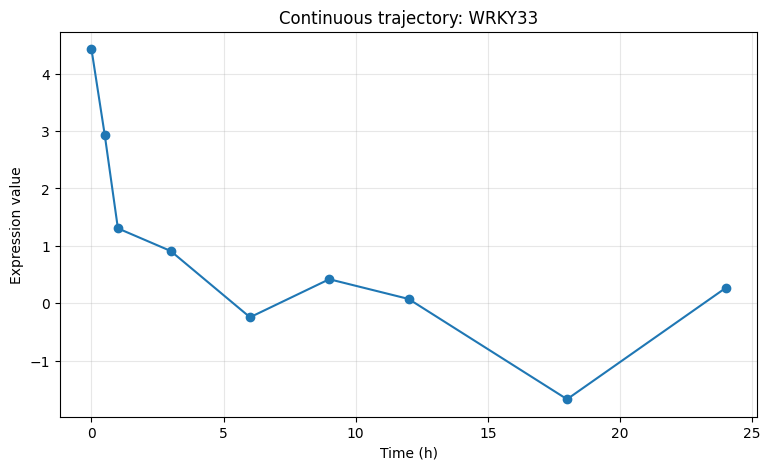

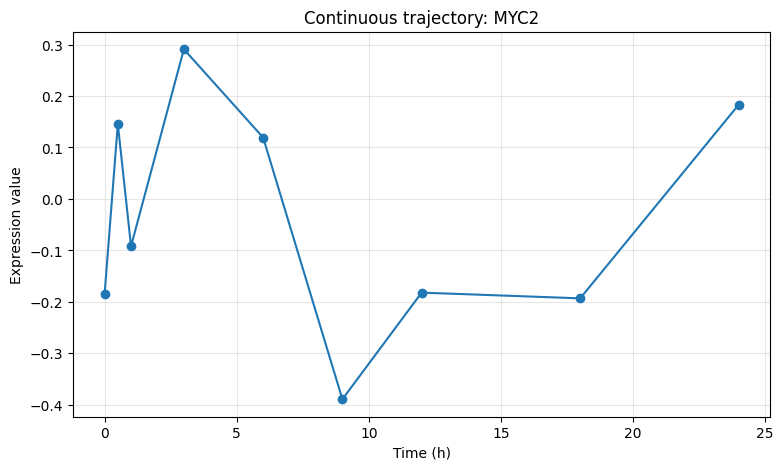

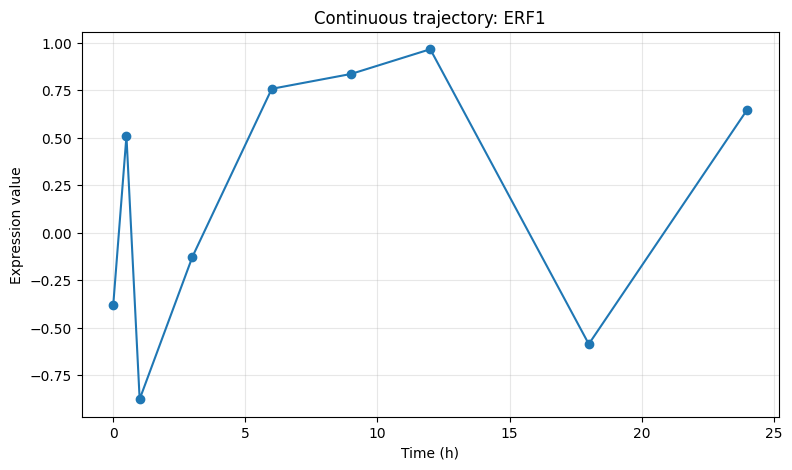

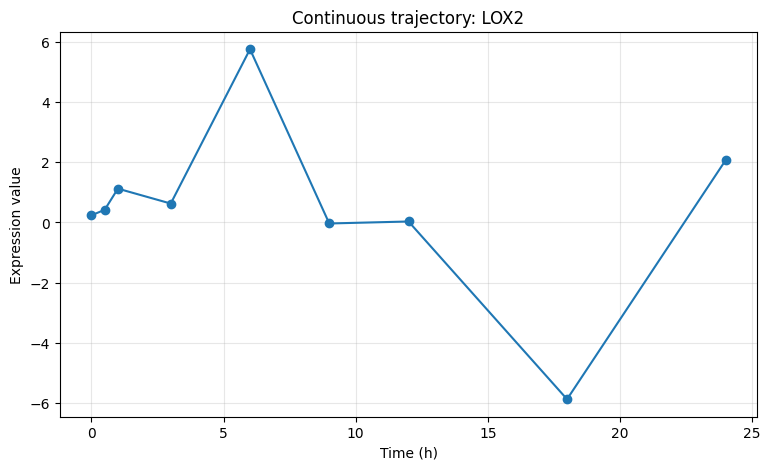

In [ ]:
# =========================
# 5. Plot continuous trajectories
# =========================
for gene in genes:
    plt.figure()
    plt.plot(times, df[gene].values, marker="o")
    plt.title(f"Continuous trajectory: {gene}")
    plt.xlabel("Time (h)")
    plt.ylabel("Expression value")
    plt.grid(True, alpha=0.3)
    plt.show()

## 6. Plot the binarized trajectory

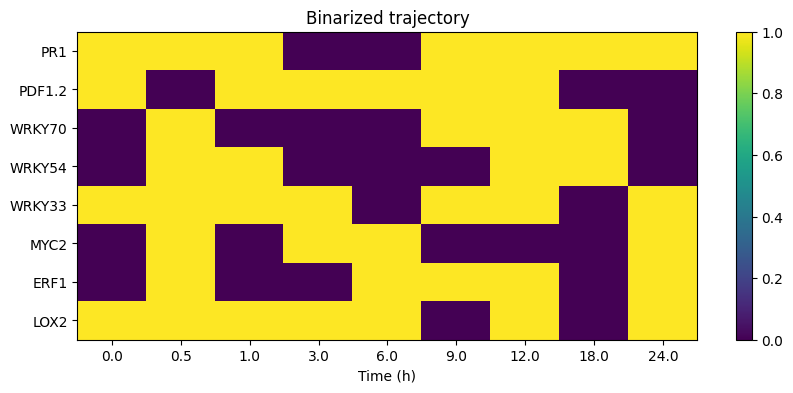

,Time(h),PR1,PDF1.2,WRKY70,WRKY54,WRKY33,MYC2,ERF1,LOX2
0,0.0,1,1,0,0,1,0,0,1
1,0.5,1,0,1,1,1,1,1,1
2,1.0,1,1,0,1,1,0,0,1
3,3.0,0,1,0,0,1,1,0,1
4,6.0,0,1,0,0,0,1,1,1
5,9.0,1,1,1,0,1,0,1,0
6,12.0,1,1,1,1,1,0,1,1
7,18.0,1,0,1,1,0,0,0,0
8,24.0,1,0,0,0,1,1,1,1


In [ ]:
# =========================
# 6. Plot the binarized trajectory
# =========================
binary_df = df.copy()
binary_df[genes] = (binary_df[genes] > 0).astype(int)

plt.figure(figsize=(10, 4))
plt.imshow(binary_df[genes].T, aspect="auto")
plt.yticks(range(len(genes)), genes)
plt.xticks(range(len(times)), times)
plt.xlabel("Time (h)")
plt.title("Binarized trajectory")
plt.colorbar()
plt.show()

display(binary_df)

## 7. Model definitions

The notebook uses:

- `RFRegressorWrapper`
- `MLPRegressorWrapper`
- `SimpleTBN` (replaceable)

In [ ]:
# =========================
# 7. Model definitions
# =========================

class RFRegressorWrapper:
    def __init__(self, n_estimators=300, max_depth=3, random_state=0):
        self.model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state
        )

    def fit(self, X, Y):
        self.model.fit(X, Y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def feature_importances_matrix(self, n_outputs):
        # sklearn reports one importance vector for multi-output RF
        base = self.model.feature_importances_
        return np.tile(base.reshape(-1, 1), (1, n_outputs))


class MLPRegressorWrapper:
    def __init__(self, hidden_layer_sizes=(12,), alpha=1e-2, random_state=0, max_iter=5000):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.random_state = random_state
        self.max_iter = max_iter
        self.x_scaler = StandardScaler()
        self.y_scaler = StandardScaler()
        self.model = MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="relu",
            solver="lbfgs",
            alpha=alpha,
            random_state=random_state,
            max_iter=max_iter
        )

    def fit(self, X, Y):
        Xs = self.x_scaler.fit_transform(X)
        Ys = self.y_scaler.fit_transform(Y)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.model.fit(Xs, Ys)
        return self

    def predict(self, X):
        Xs = self.x_scaler.transform(X)
        pred_scaled = np.atleast_2d(self.model.predict(Xs))
        return self.y_scaler.inverse_transform(pred_scaled)


# ---------- Simple TBN baseline ----------
class ConstantBinaryModel:
    def __init__(self, constant_value):
        self.constant_value = int(constant_value)

    def predict(self, X):
        return np.full((len(X),), self.constant_value, dtype=int)


class SimpleTBN:
    '''
    Simple node-wise linear-threshold TBN baseline.

    Each target gene is learned independently on the binarized transitions.
    The resulting model predicts binary next states using a hard threshold.

    '''
    def __init__(self, learning_rate=1.0, max_epochs=100):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.W = None
        self.b = None
        self.models = None

    def _fit_perceptron_node(self, X, y):
        # Manual perceptron to avoid dependency on sklearn handling 1-class edge cases.
        if len(np.unique(y)) < 2:
            return ConstantBinaryModel(y[0]), np.zeros(X.shape[1]), 0.0

        w = np.zeros(X.shape[1], dtype=float)
        b = 0.0

        for _ in range(self.max_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = 1 if np.dot(xi, w) + b >= 0 else 0
                update = self.learning_rate * (yi - pred)
                if update != 0:
                    w += update * xi
                    b += update
                    errors += 1
            if errors == 0:
                break

        class LearnedNode:
            def __init__(self, w, b):
                self.w = w
                self.b = b
            def predict(self, X):
                scores = X @ self.w + self.b
                return (scores >= 0).astype(int)

        return LearnedNode(w, b), w, b

    def fit(self, X, Y):
        n_inputs = X.shape[1]
        n_outputs = Y.shape[1]
        self.W = np.zeros((n_inputs, n_outputs), dtype=float)
        self.b = np.zeros(n_outputs, dtype=float)
        self.models = []

        for j in range(n_outputs):
            node_model, wj, bj = self._fit_perceptron_node(X, Y[:, j])
            self.models.append(node_model)
            self.W[:, j] = wj
            self.b[j] = bj

        return self

    def predict(self, X):
        cols = []
        for model in self.models:
            cols.append(np.asarray(model.predict(X)).reshape(-1, 1))
        return np.hstack(cols)

## 8. Helper functions

In [ ]:
# =========================
# 8. Helper functions
# =========================

def binarize_sign(arr):
    return (np.asarray(arr) > 0).astype(int)

def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

def binary_metrics(y_true_bin, y_pred_bin):
    y_true_bin = np.asarray(y_true_bin).astype(int)
    y_pred_bin = np.asarray(y_pred_bin).astype(int)
    return {
        "bin_acc": (y_true_bin == y_pred_bin).mean(),
        "hamming": np.not_equal(y_true_bin, y_pred_bin).sum(),
    }

def build_model(model_name, seed=0):
    if model_name == "RF":
        return RFRegressorWrapper(random_state=seed)
    elif model_name == "MLP":
        return MLPRegressorWrapper(random_state=seed)
    elif model_name == "TBN":
        return SimpleTBN()
    else:
        raise ValueError(f"Unknown model: {model_name}")

## 9. Rolling-origin evaluation

We use expanding-window evaluation:

- train on the first 3 transitions, test on the 4th,
- then train on the first 4 transitions, test on the 5th,
- ...
- until the last transition.

For the MLP, we repeat multiple seeds and aggregate the results.

In [ ]:
# =========================
# 9. Rolling-origin evaluation
# =========================

def rolling_origin_evaluation(
    X_cont_dt, Y_cont, X_bin, Y_bin,
    min_train_size=3,
    mlp_seeds=(0, 1, 2, 3, 4)
):
    rows = []

    n_transitions = len(X_cont_dt)

    for train_end in range(min_train_size, n_transitions):
        split_label = f"{train_end}: test {transition_labels[train_end]}"

        # ----- Random Forest -----
        rf = build_model("RF", seed=0).fit(X_cont_dt[:train_end], Y_cont[:train_end])
        rf_pred = rf.predict(X_cont_dt[train_end:train_end+1])

        row = {
            "model": "RF",
            "train_size": train_end,
            "test_transition": transition_labels[train_end],
            **regression_metrics(Y_cont[train_end:train_end+1], rf_pred),
            **binary_metrics(Y_bin[train_end:train_end+1], binarize_sign(rf_pred)),
        }
        rows.append(row)

        # ----- MLP: repeated seeds -----
        mlp_seed_rows = []
        for seed in mlp_seeds:
            mlp = build_model("MLP", seed=seed).fit(X_cont_dt[:train_end], Y_cont[:train_end])
            mlp_pred = mlp.predict(X_cont_dt[train_end:train_end+1])

            mlp_seed_rows.append({
                "model": "MLP",
                "train_size": train_end,
                "test_transition": transition_labels[train_end],
                "seed": seed,
                **regression_metrics(Y_cont[train_end:train_end+1], mlp_pred),
                **binary_metrics(Y_bin[train_end:train_end+1], binarize_sign(mlp_pred)),
            })

        rows.extend(mlp_seed_rows)

        # ----- TBN -----
        tbn = build_model("TBN").fit(X_bin[:train_end], Y_bin[:train_end])
        tbn_pred = tbn.predict(X_bin[train_end:train_end+1])

        row = {
            "model": "TBN",
            "train_size": train_end,
            "test_transition": transition_labels[train_end],
            "mae": np.nan,
            "rmse": np.nan,
            **binary_metrics(Y_bin[train_end:train_end+1], tbn_pred),
        }
        rows.append(row)

    return pd.DataFrame(rows)

results_long = rolling_origin_evaluation(
    X_cont_dt=X_cont_dt,
    Y_cont=Y_cont,
    X_bin=X_bin,
    Y_bin=Y_bin,
    min_train_size=3,
    mlp_seeds=(0,1,2,3,4)
)

display(results_long.head(20))

,model,train_size,test_transition,mae,rmse,bin_acc,hamming,seed
0,RF,3,3.0→6.0,1.428720,2.037781,0.500,4,NaN
1,MLP,3,3.0→6.0,1.077280,1.914345,0.750,2,0.0
2,MLP,3,3.0→6.0,1.085557,1.908592,0.750,2,1.0
3,MLP,3,3.0→6.0,1.084917,1.906641,0.750,2,2.0
4,MLP,3,3.0→6.0,1.084132,1.915032,0.750,2,3.0
5,MLP,3,3.0→6.0,1.084599,1.901867,0.750,2,4.0
6,TBN,3,3.0→6.0,NaN,NaN,0.500,4,NaN
7,RF,4,6.0→9.0,0.866523,1.394585,0.625,3,NaN
8,MLP,4,6.0→9.0,1.170838,1.464984,0.500,4,0.0
9,MLP,4,6.0→9.0,1.337578,1.603305,0.375,5,1.0


## 10. Aggregate results for the paper

In [ ]:
# =========================
# 10. Aggregate results
# =========================

# Summary across all splits
summary = (
    results_long
    .groupby("model")[["mae", "rmse", "bin_acc", "hamming"]]
    .agg(["mean", "std"])
    .round(4)
)

print("Overall summary:")
display(summary)

# A cleaner flat table for the paper
summary_flat = results_long.groupby("model").agg(
    mae_mean=("mae", "mean"),
    mae_std=("mae", "std"),
    rmse_mean=("rmse", "mean"),
    rmse_std=("rmse", "std"),
    bin_acc_mean=("bin_acc", "mean"),
    bin_acc_std=("bin_acc", "std"),
    hamming_mean=("hamming", "mean"),
    hamming_std=("hamming", "std"),
).round(4)

print("Flat summary table:")
display(summary_flat)

Overall summary:


mae            rmse         bin_acc         hamming        
         mean     std    mean     std    mean     std    mean     std
model                                                                
MLP    2.0891  0.9418  3.1056  1.3215   0.495  0.1892    4.04  1.5133
RF     1.9099  0.8860  2.8363  1.1471   0.500  0.2339    4.00  1.8708
TBN       NaN     NaN     NaN     NaN   0.550  0.1118    3.60  0.8944

Flat summary table:


,mae_mean,mae_std,rmse_mean,rmse_std,bin_acc_mean,bin_acc_std,hamming_mean,hamming_std
model,,,,,,,,
MLP,2.0891,0.9418,3.1056,1.3215,0.495,0.1892,4.04,1.5133
RF,1.9099,0.8860,2.8363,1.1471,0.500,0.2339,4.00,1.8708
TBN,NaN,NaN,NaN,NaN,0.550,0.1118,3.60,0.8944


## 11. Optional LaTeX-style table strings

This cell prints simple strings you can adapt into the Results section.

In [ ]:
# =========================
# 11. Optional LaTeX-ready strings
# =========================

def mean_std_str(m, s, digits=3):
    if pd.isna(m):
        return "--"
    if pd.isna(s):
        return f"{m:.{digits}f}"
    return f"{m:.{digits}f} $\\pm$ {s:.{digits}f}"

latex_rows = []
for model, row in summary_flat.iterrows():
    latex_rows.append(
        " & ".join([
            model,
            mean_std_str(row["mae_mean"], row["mae_std"]),
            mean_std_str(row["rmse_mean"], row["rmse_std"]),
            mean_std_str(row["bin_acc_mean"], row["bin_acc_std"]),
            mean_std_str(row["hamming_mean"], row["hamming_std"]),
        ]) + r" \\"
    )

print("Suggested LaTeX rows:")
for r in latex_rows:
    print(r)

Suggested LaTeX rows:
MLP & 2.089 $\pm$ 0.942 & 3.106 $\pm$ 1.321 & 0.495 $\pm$ 0.189 & 4.040 $\pm$ 1.513 \\
RF & 1.910 $\pm$ 0.886 & 2.836 $\pm$ 1.147 & 0.500 $\pm$ 0.234 & 4.000 $\pm$ 1.871 \\
TBN & -- & -- & 0.550 $\pm$ 0.112 & 3.600 $\pm$ 0.894 \\


## 12. Plot rolling-origin performance by split

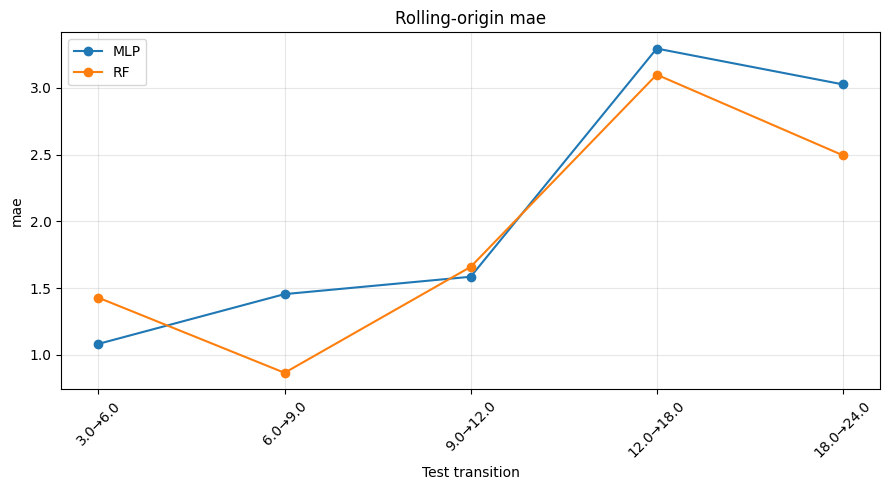

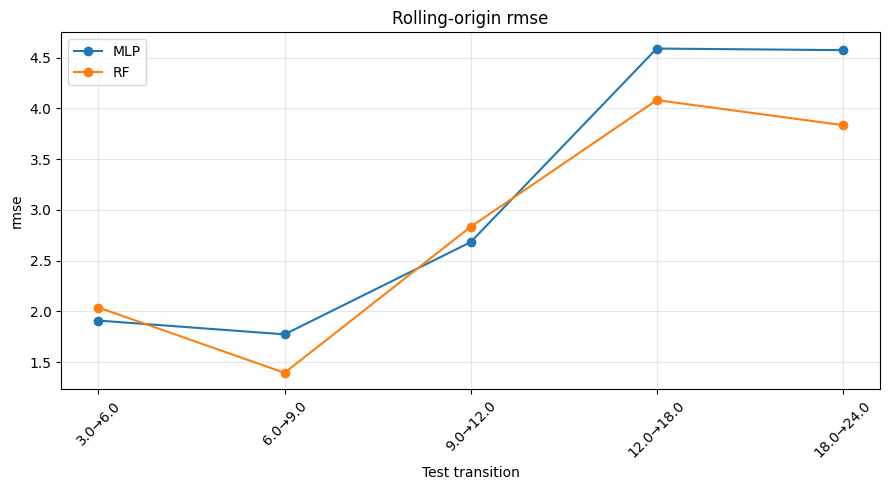

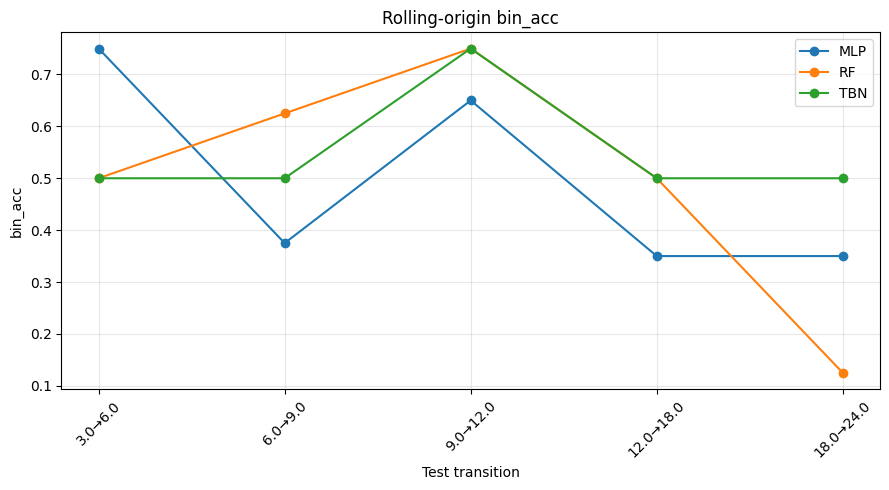

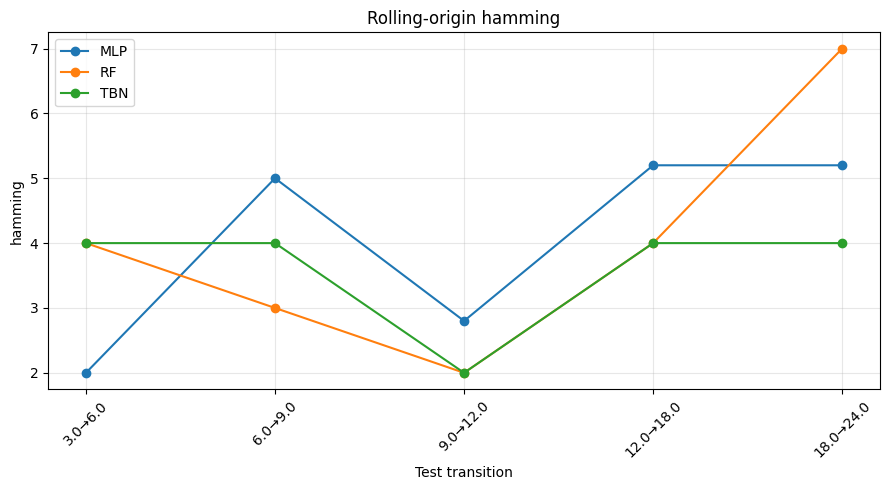

In [ ]:
# =========================
# 12. Plot performance by split
# =========================

import os

# Carpeta opcional para guardar figuras
os.makedirs("figures", exist_ok=True)

# For MLP, average over seeds within each split
plot_df = results_long.copy()
plot_df = (
    plot_df.groupby(["model", "train_size", "test_transition"], as_index=False)
    .agg({
        "mae": "mean",
        "rmse": "mean",
        "bin_acc": "mean",
        "hamming": "mean"
    })
)

for metric in ["mae", "rmse", "bin_acc", "hamming"]:
    plt.figure()
    for model in plot_df["model"].unique():
        sub = plot_df[plot_df["model"] == model]
        if sub[metric].notna().any():
            plt.plot(sub["test_transition"], sub[metric], marker="o", label=model)
    plt.title(f"Rolling-origin {metric}")
    plt.xlabel("Test transition")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures/rolling_{metric}.pdf", bbox_inches="tight")
    plt.show()

## 13. Fit final models on all available transitions

These full-data models are used for the multi-step rollout and interpretability visualizations.

In [ ]:
# =========================
# 13. Fit final models on all transitions
# =========================

rf_final = build_model("RF", seed=0).fit(X_cont_dt, Y_cont)
mlp_final_models = [build_model("MLP", seed=s).fit(X_cont_dt, Y_cont) for s in [0,1,2,3,4]]
tbn_final = build_model("TBN").fit(X_bin, Y_bin)

print("Final models fitted.")

Final models fitted.


## 14. Multi-step rollout

We start from the first observed state and recursively predict forward.

For the continuous models, the next input includes:

- the predicted continuous state,
- the observed next \(\Delta t\) from the original timeline.

This keeps the rollout aligned with the biological sampling schedule.

In [ ]:
# =========================
# 14. Multi-step rollout
# =========================

def rollout_continuous(model, x0, delta_t_sequence):
    preds = [x0.copy()]
    current = x0.copy()
    for dt in delta_t_sequence:
        x_in = np.hstack([current, [dt]]).reshape(1, -1)
        nxt = model.predict(x_in).reshape(-1)
        preds.append(nxt.copy())
        current = nxt
    return np.vstack(preds)

def rollout_tbn(model, x0_bin, n_steps):
    preds = [x0_bin.copy()]
    current = x0_bin.copy()
    for _ in range(n_steps):
        nxt = model.predict(current.reshape(1, -1)).reshape(-1)
        preds.append(nxt.copy())
        current = nxt
    return np.vstack(preds)

# Initial states
x0_cont = df[genes].values[0]
x0_bin = (x0_cont > 0).astype(int)

delta_t_sequence = (times[1:] - times[:-1])

rf_rollout = rollout_continuous(rf_final, x0_cont, delta_t_sequence)

mlp_rollouts = [
    rollout_continuous(model, x0_cont, delta_t_sequence)
    for model in mlp_final_models
]
mlp_rollout_mean = np.mean(np.stack(mlp_rollouts, axis=0), axis=0)

tbn_rollout = rollout_tbn(tbn_final, x0_bin, n_steps=len(delta_t_sequence))

observed_cont = df[genes].values
observed_bin = (observed_cont > 0).astype(int)
rf_rollout_bin = binarize_sign(rf_rollout)
mlp_rollout_bin = binarize_sign(mlp_rollout_mean)

print("Observed continuous shape:", observed_cont.shape)
print("RF rollout shape:", rf_rollout.shape)
print("MLP rollout mean shape:", mlp_rollout_mean.shape)
print("TBN rollout shape:", tbn_rollout.shape)

Observed continuous shape: (9, 8)
RF rollout shape: (9, 8)
MLP rollout mean shape: (9, 8)
TBN rollout shape: (9, 8)


## 15. Compare observed and rollout trajectories

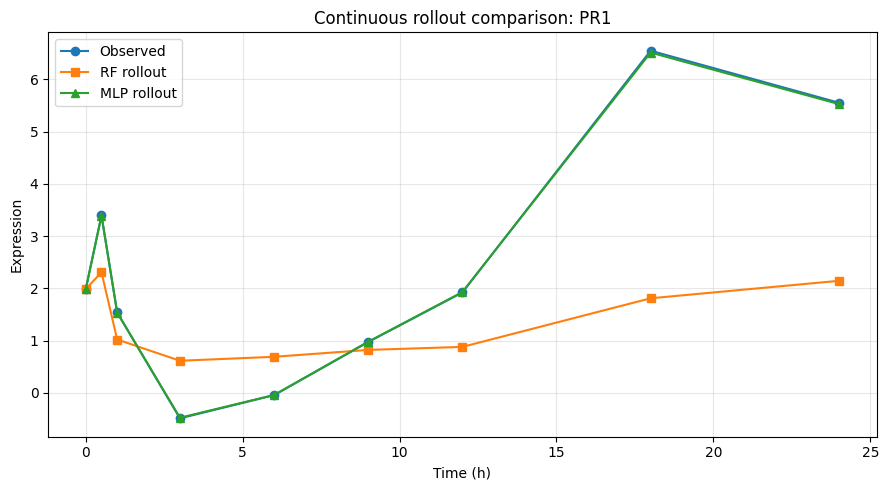

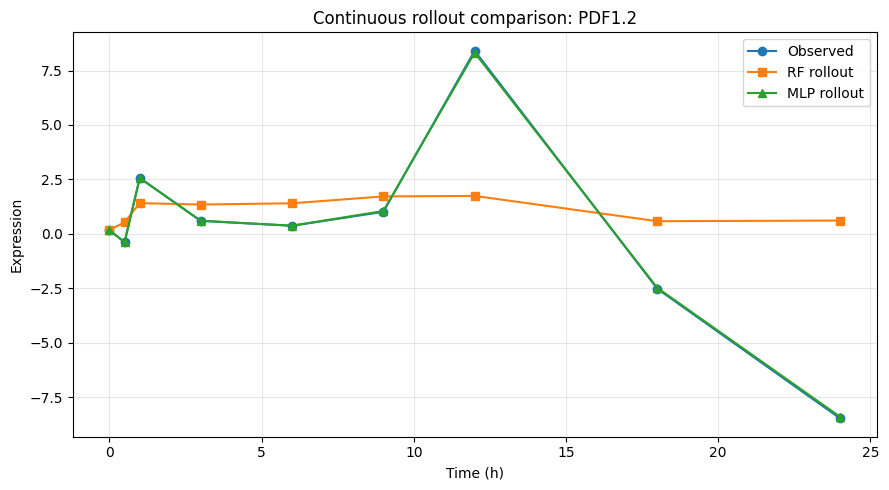

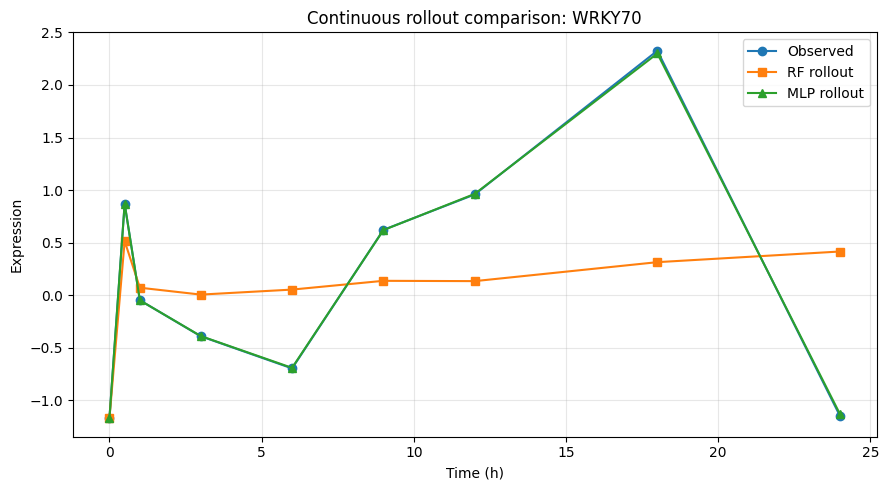

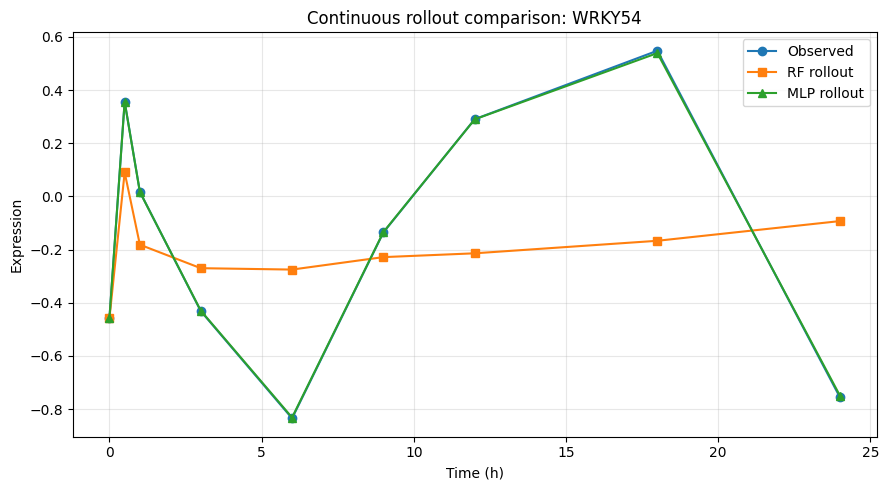

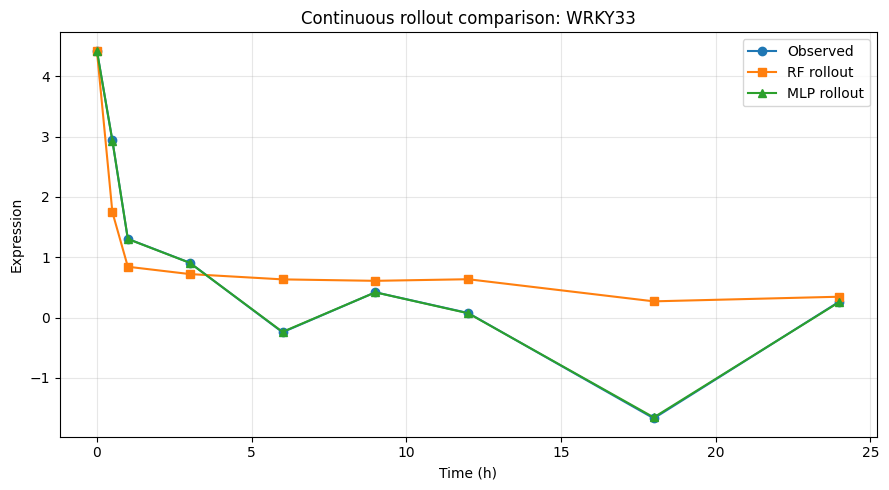

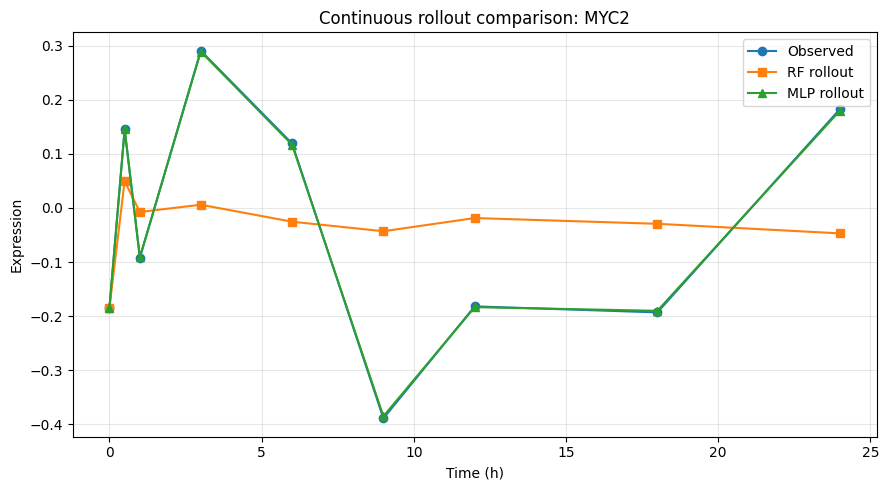

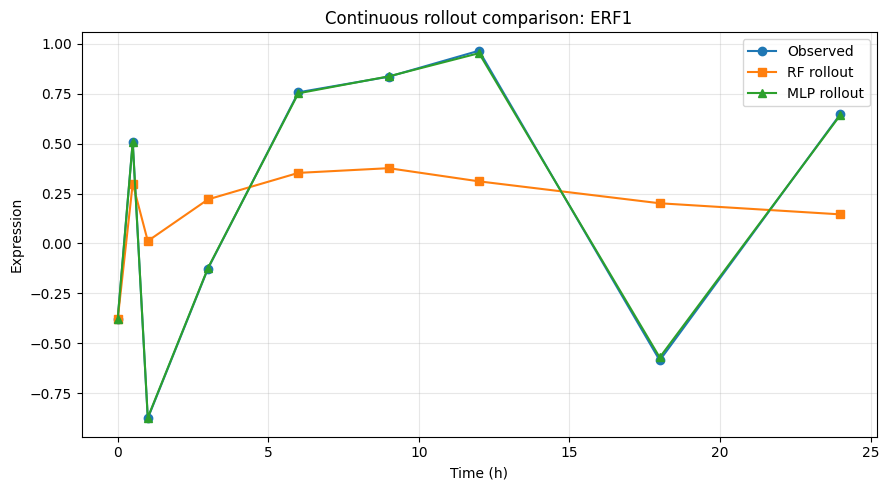

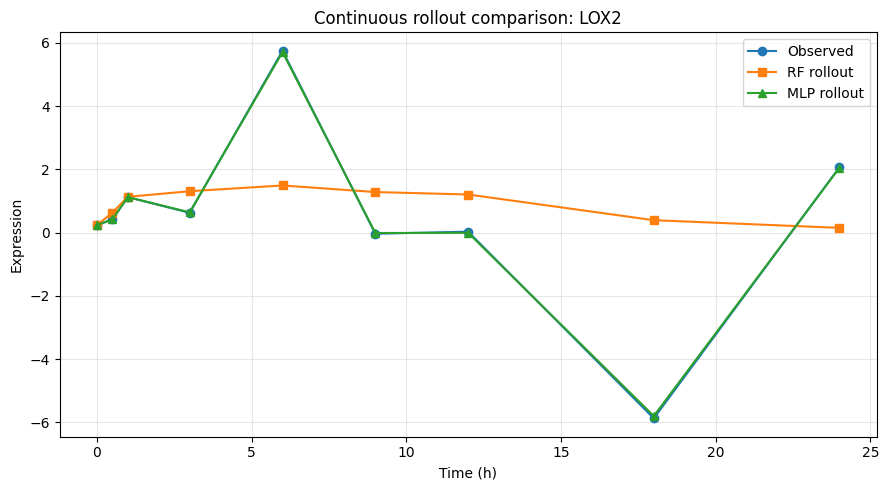

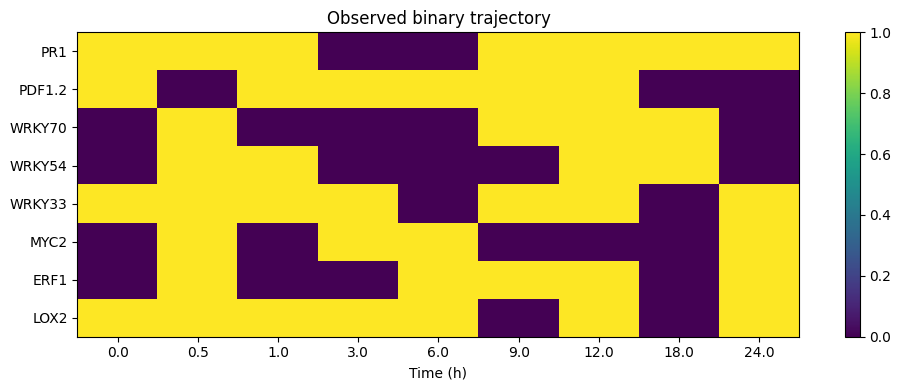

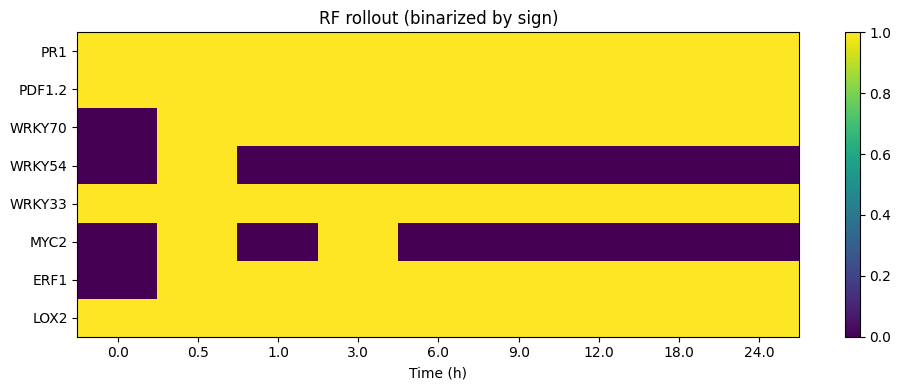

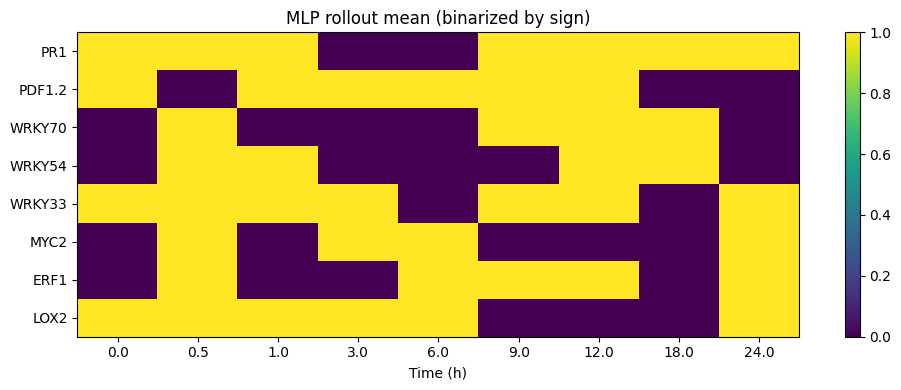

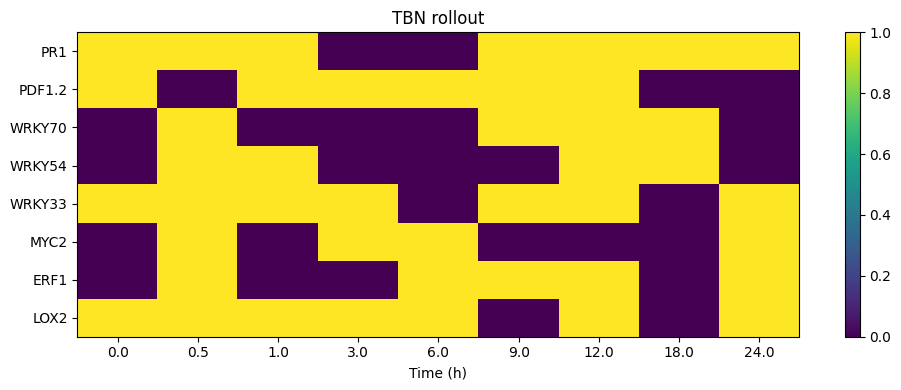

In [ ]:
# =========================
# 15. Trajectory comparison plots
# =========================

import os
os.makedirs("figures", exist_ok=True)

# Continuous trajectories: observed vs RF vs MLP
for gene_idx, gene in enumerate(genes):
    plt.figure()
    plt.plot(times, observed_cont[:, gene_idx], marker="o", label="Observed")
    plt.plot(times, rf_rollout[:, gene_idx], marker="s", label="RF rollout")
    plt.plot(times, mlp_rollout_mean[:, gene_idx], marker="^", label="MLP rollout")
    plt.title(f"Continuous rollout comparison: {gene}")
    plt.xlabel("Time (h)")
    plt.ylabel("Expression")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figures/rollout_{gene}.pdf", bbox_inches="tight")
    plt.show()

# Binary heatmaps
def plot_binary_heatmap(matrix, title, filename):
    plt.figure(figsize=(10, 4))
    plt.imshow(matrix.T, aspect="auto")
    plt.yticks(range(len(genes)), genes)
    plt.xticks(range(len(times)), times)
    plt.xlabel("Time (h)")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"figures/{filename}.pdf", bbox_inches="tight")
    plt.show()

plot_binary_heatmap(observed_bin, "Observed binary trajectory", "observed_binary_heatmap")
plot_binary_heatmap(rf_rollout_bin, "RF rollout (binarized by sign)", "rf_binary_rollout_heatmap")
plot_binary_heatmap(mlp_rollout_bin, "MLP rollout mean (binarized by sign)", "mlp_binary_rollout_heatmap")
plot_binary_heatmap(tbn_rollout, "TBN rollout", "tbn_binary_rollout_heatmap")

## 16. Rollout fidelity metrics

We compare each rollout against the observed binary trajectory.

In [ ]:
# =========================
# 16. Rollout fidelity metrics
# =========================

def trajectory_fidelity(y_true_bin, y_pred_bin):
    # Average binary accuracy over all time points and genes
    acc = (y_true_bin == y_pred_bin).mean()
    hamming_total = np.not_equal(y_true_bin, y_pred_bin).sum()
    hamming_per_time = np.not_equal(y_true_bin, y_pred_bin).sum(axis=1)
    return {
        "trajectory_bin_acc": acc,
        "trajectory_hamming_total": hamming_total,
        "trajectory_hamming_mean_per_time": hamming_per_time.mean()
    }

rollout_metrics = pd.DataFrame([
    {"model": "RF_rollout", **trajectory_fidelity(observed_bin, rf_rollout_bin)},
    {"model": "MLP_rollout", **trajectory_fidelity(observed_bin, mlp_rollout_bin)},
    {"model": "TBN_rollout", **trajectory_fidelity(observed_bin, tbn_rollout)},
]).round(4)

display(rollout_metrics)

,model,trajectory_bin_acc,trajectory_hamming_total,trajectory_hamming_mean_per_time
0,RF_rollout,0.7083,21,2.3333
1,MLP_rollout,0.9861,1,0.1111
2,TBN_rollout,1.0000,0,0.0000


## 17. Interpretability: Random Forest feature importances

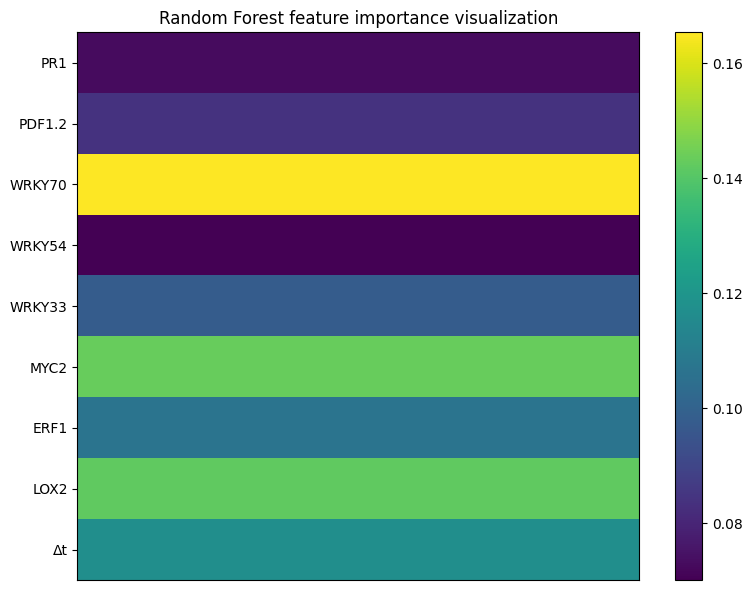

,PR1,PDF1.2,WRKY70,WRKY54,WRKY33,MYC2,ERF1,LOX2
PR1,0.0731,0.0731,0.0731,0.0731,0.0731,0.0731,0.0731,0.0731
PDF1.2,0.0839,0.0839,0.0839,0.0839,0.0839,0.0839,0.0839,0.0839
WRKY70,0.1654,0.1654,0.1654,0.1654,0.1654,0.1654,0.1654,0.1654
WRKY54,0.0701,0.0701,0.0701,0.0701,0.0701,0.0701,0.0701,0.0701
WRKY33,0.0977,0.0977,0.0977,0.0977,0.0977,0.0977,0.0977,0.0977
MYC2,0.1434,0.1434,0.1434,0.1434,0.1434,0.1434,0.1434,0.1434
ERF1,0.1070,0.1070,0.1070,0.1070,0.1070,0.1070,0.1070,0.1070
LOX2,0.1422,0.1422,0.1422,0.1422,0.1422,0.1422,0.1422,0.1422
Δt,0.1171,0.1171,0.1171,0.1171,0.1171,0.1171,0.1171,0.1171


In [ ]:
# =========================
# 17. RF feature importances
# =========================

import os
os.makedirs("figures", exist_ok=True)

rf_importance_matrix = rf_final.feature_importances_matrix(n_outputs=len(genes))
rf_feature_names = genes + ["Δt"]

plt.figure(figsize=(8, 6))
plt.imshow(rf_importance_matrix, aspect="auto")
plt.yticks(range(len(rf_feature_names)), rf_feature_names)
plt.xticks([])  # remove x-axis gene names
plt.title("Random Forest feature importance visualization")
plt.colorbar()
plt.tight_layout()
plt.savefig("figures/rf_feature_importance_heatmap.pdf", bbox_inches="tight")
plt.show()

rf_importance_df = pd.DataFrame(
    rf_importance_matrix,
    index=rf_feature_names,
    columns=genes
)
display(rf_importance_df.round(4))

## 18. Interpretability: TBN weight matrix

,PR1,PDF1.2,WRKY70,WRKY54,WRKY33,MYC2,ERF1,LOX2
PR1,1.0,0.0,0.0,1.0,3.0,1.0,-1.0,4.0
PDF1.2,0.0,-1.0,4.0,0.0,-1.0,1.0,3.0,-3.0
WRKY70,4.0,-6.0,1.0,3.0,-1.0,-2.0,1.0,0.0
WRKY54,-1.0,3.0,-5.0,-3.0,-1.0,1.0,-3.0,-1.0
WRKY33,-1.0,6.0,-2.0,3.0,-3.0,0.0,-1.0,2.0
MYC2,0.0,9.0,-4.0,-2.0,0.0,-1.0,1.0,1.0
ERF1,4.0,1.0,6.0,4.0,0.0,-6.0,-1.0,-4.0
LOX2,-1.0,-7.0,-1.0,-1.0,0.0,0.0,-2.0,-1.0


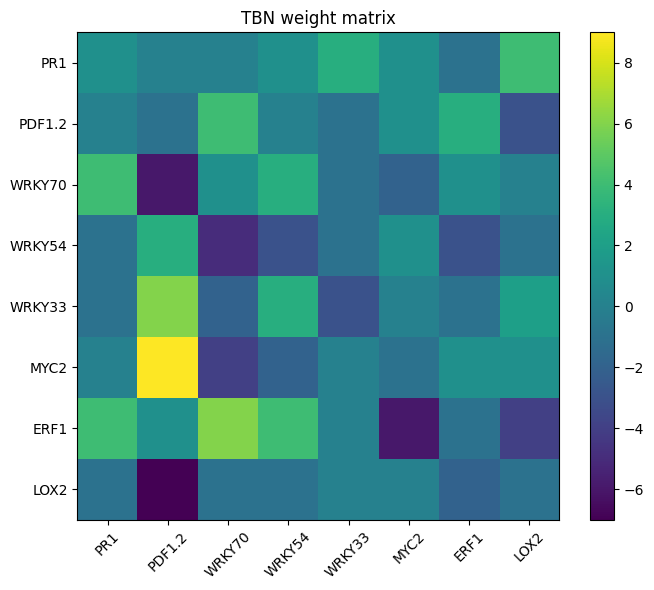

In [ ]:
# =========================
# 18. TBN weight matrix
# =========================

import os
os.makedirs("figures", exist_ok=True)

tbn_weight_df = pd.DataFrame(tbn_final.W, index=genes, columns=genes)
display(tbn_weight_df)

plt.figure(figsize=(7, 6))
plt.imshow(tbn_weight_df.values, aspect="auto")
plt.xticks(range(len(genes)), genes, rotation=45)
plt.yticks(range(len(genes)), genes)
plt.title("TBN weight matrix")
plt.colorbar()
plt.tight_layout()
plt.savefig("figures/tbn_weight_matrix_heatmap.pdf", bbox_inches="tight")
plt.show()

## 19. Export tables to CSV

These files can be downloaded from Colab and used in the paper.

In [ ]:
# =========================
# 19. Export results
# =========================
results_long.to_csv("results_long.csv", index=False)
summary_flat.to_csv("results_summary.csv")
rollout_metrics.to_csv("rollout_metrics.csv", index=False)

print("Saved:")
print("- results_long.csv")
print("- results_summary.csv")
print("- rollout_metrics.csv")

Saved:
- results_long.csv
- results_summary.csv
- rollout_metrics.csv


## 20. Optional: quick textual summary

This cell prints a compact summary.

In [ ]:
# =========================
# 20. Quick textual summary
# =========================
print("=== One-step rolling-origin summary ===")
print(summary_flat)

print("\n=== Rollout fidelity summary ===")
print(rollout_metrics)

=== One-step rolling-origin summary ===
       mae_mean  mae_std  rmse_mean  rmse_std  bin_acc_mean  bin_acc_std  \
model                                                                      
MLP      2.0891   0.9418     3.1056    1.3215         0.495       0.1892   
RF       1.9099   0.8860     2.8363    1.1471         0.500       0.2339   
TBN         NaN      NaN        NaN       NaN         0.550       0.1118   

       hamming_mean  hamming_std  
model                             
MLP            4.04       1.5133  
RF             4.00       1.8708  
TBN            3.60       0.8944  

=== Rollout fidelity summary ===
         model  trajectory_bin_acc  trajectory_hamming_total  \
0   RF_rollout              0.7083                        21   
1  MLP_rollout              0.9861                         1   
2  TBN_rollout              1.0000                         0   

   trajectory_hamming_mean_per_time  
0                            2.3333  
1                            0.1111  